# Loan Offer Propensity Model 

**Business problem** 

The bank wants to offer their customers a loan, they want to identify which customers to approach and if there is no bias in the data. 

This notebook is the exploratory companion to the production pipeline in
`pipelines/train_model.py`. All of the real logic:
- data cleaning, 
- feature engineering, 
- EDA checks, 
- modelling, 
- fairness assessment,

all lives in `src/` and is unit-testable/reusable outside a notebook.

This notebook calls into those functions and narrates the findings, rather than reimplementing
the logic inline. That split keeps one source of truth - if you change how a
KPI is computed, you change it in `src/features.py`, and both this notebook
and the production pipeline pick it up.

**Why PySpark**: 

Using PySpark means the same code that explore data in this notebook is the same code that would run in  production. 


**Charts in this notebook** 

Are built from `src/viz.py`, which follows the same rule as `src/eda_checks.py`: 
- aggregation, 
- filtering, 
- sampling,

all happens in Spark; only a small, already-reduced pandas DataFrame is ever
collected to the driver for matplotlib to draw. No chart in this notebook
collects a full, un-aggregated column.

**Something to Note !!** 

- The target variable is `loans.OUTCOME` (a real historical decision), not
  a hand-written business rule -- training on the rule would be circular.
- Loan-history features are computed point-in-time (only using
  applications strictly before the one being scored),  as this solves the target leakage problem.
- A bias/fairness assessment (disparate impact by gender/age, a
  with-vs-without-gender AUC comparison) is a first-class part of the
  pipeline.
- EDA/data-quality checks: 
  - referential integrity, 
  - outlier detection, 
  - distribution shift tests, 
  - threshold derivation, 

run as a reusable module (`src/eda_checks.py`) and are persisted as a report on
  every training run.

**Running in Production**

We use grafana dashboard to monitor key metrics:
- Prediction volume and latency: every score call is counted and timed - catches a serving outage.
- Score distribution
- Feature drift: we track PSI index to track when to consider retraining:
  - less than 0.01 stable
  - 0.10 - 0.25 monitor
  - more than 0.25 retrain
- Faireness over time


In [61]:
import sys
sys.path.insert(0, "..")  # so `import src...` works when this notebook runs from notebooks/

import matplotlib.pyplot as plt

from src.utils import get_spark_session
from src.data_prep import load_and_clean
from src import eda_checks as eda
from src import features as feat
from src import modeling as model_lib
from src import viz
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

# Initialize Spark session
spark = get_spark_session(app_name="loan_propensity_notebook")


## 1. Load and clean the raw data

`load_and_clean` applies the fixes identified during EDA: GENDER
normalisation (whitespace/casing collapsed to a canonical 'Female'/'Male',
with anything else kept as an explicit 'Unknown' rather than guessed at),
AGE outlier handling (values outside a plausible human lifespan are treated
as missing, then median-imputed), and INCOME imputation. See
`src/data_prep.py` for the full reasoning behind each choice.


In [32]:
CUSTOMERS_PATH = "../data/customers.parquet"     # or .parquet
LOANS_PATH = "../data/loans.parquet"
TRANSACTIONS_PATH = "../data/transactions.parquet"

customers, loans, transactions = load_and_clean(
    spark, CUSTOMERS_PATH, LOANS_PATH, TRANSACTIONS_PATH
)
customers.cache(); loans.cache(); transactions.cache()

print(f"customers: {customers.count()} rows")
print(f"loans: {loans.count()} rows")
print(f"transactions: {transactions.count()} rows")
customers.show(5)


26/08/13 22:15:12 WARN CacheManager: Asked to cache already cached data.        
26/08/13 22:15:12 WARN CacheManager: Asked to cache already cached data.
26/08/13 22:15:12 WARN CacheManager: Asked to cache already cached data.


customers: 2500 rows
loans: 3203 rows
transactions: 91931 rows
+--------+------+---+-------+
|      ID|GENDER|AGE| INCOME|
+--------+------+---+-------+
|M5FQZHG1|Female| 37|10843.0|
|JPOALDTW|  Male| 38| 9419.0|
|QHJXRE6A|  Male| 37|10850.0|
|LKS17XRW|  Male| 35|10107.0|
|V5UPOIAW|Female| 34|10323.0|
+--------+------+---+-------+
only showing top 5 rows



Gender, after cleaning, and the income distribution (with sentinel/outlier
handling already applied in `clean_customers`) -- the two data-quality fixes
that would otherwise silently corrupt everything downstream.


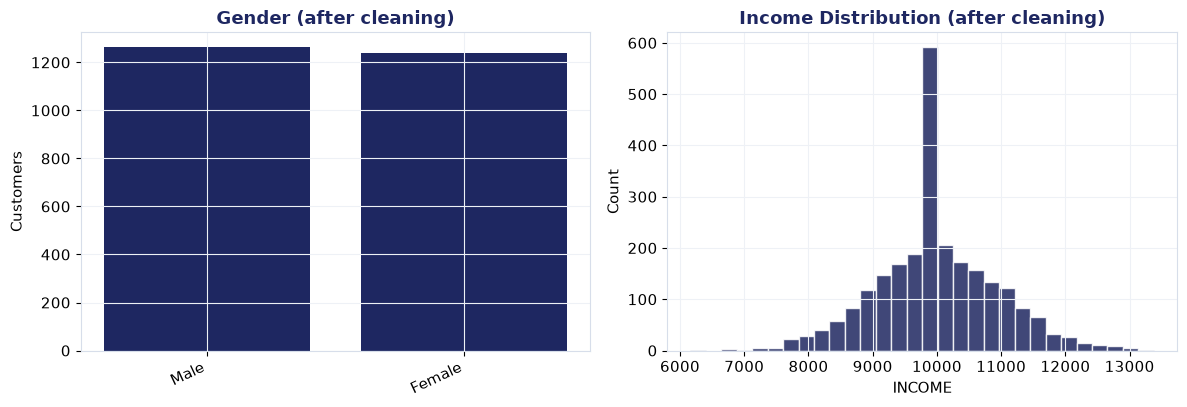

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
viz.plot_category_counts(customers, "GENDER", "Gender (after cleaning)", ax=axes[0])
viz.plot_bounded_histogram(customers, "INCOME", "Income Distribution (after cleaning)", ax=axes[1])
fig.tight_layout()
plt.show()


## 2. Derive empirical thresholds

Two feature-engineering thresholds are read off the data itself instead of
hardcoded: the "low balance" cutoff (10th percentile of positive balances)
and the age-tertile boundaries used for lifecycle segmentation. See
`eda_checks.derive_empirical_thresholds` for why this is preferable to
picking round numbers.


In [34]:
thresholds = eda.derive_empirical_thresholds(transactions, customers)
thresholds


{'low_balance_threshold': 3587.0,
 'age_tertile_33': 32.0,
 'age_tertile_66': 36.0}

## 3. Build customer-level features

One row per customer: the financial-health KPIs from the case study's
assumptions (net cash flow, balance volatility, burn rate, low-balance
frequency, credit capacity), the `customer_segment` flag (Existing
Borrower vs. Deposit-Only Prospect), lifecycle segment flags, and the
`KPI_action_quadrant` business-rule heuristic (used later only to score
prospects with no real outcome to validate against -- **not** used as the
model's training target).


In [35]:
customer_features = feat.build_customer_features(customers, loans, transactions, thresholds)
customer_features.cache()
customer_features.count()

customer_features.select(
    "ID", "customer_segment", "KPI_action_quadrant",
    "KPI_net_cash_flow", "KPI_balance_volatility_index", "KPI_repayment_track_record",
).show(5, truncate=False)


26/08/13 22:15:37 WARN CacheManager: Asked to cache already cached data.


+--------+---------------------+----------------------------+-----------------+----------------------------+--------------------------+
|ID      |customer_segment     |KPI_action_quadrant         |KPI_net_cash_flow|KPI_balance_volatility_index|KPI_repayment_track_record|
+--------+---------------------+----------------------------+-----------------+----------------------------+--------------------------+
|7VWYCGWY|Deposit-Only Prospect|Segment_D_Seasonal_Borrower |497.25           |0.3592171365086375          |-1.0                      |
|VXVT7SBC|Deposit-Only Prospect|Segment_C_Untapped_Potential|87.0             |0.43301578598779544         |-1.0                      |
|8/G9K1DJ|Deposit-Only Prospect|Segment_C_Untapped_Potential|2452.25          |0.26431990463862715         |-1.0                      |
|VEU4DTD/|Existing Borrower    |Segment_B_High_Risk         |1017.5           |0.6030743453012964          |0.0                       |
|1MAG9XOE|Deposit-Only Prospect|Segment_B_High_R

In [36]:
customer_features = feat.build_customer_features(customers, loans, transactions, thresholds)

In [37]:
customer_features = feat.cap_outlier_kpis(customer_features)

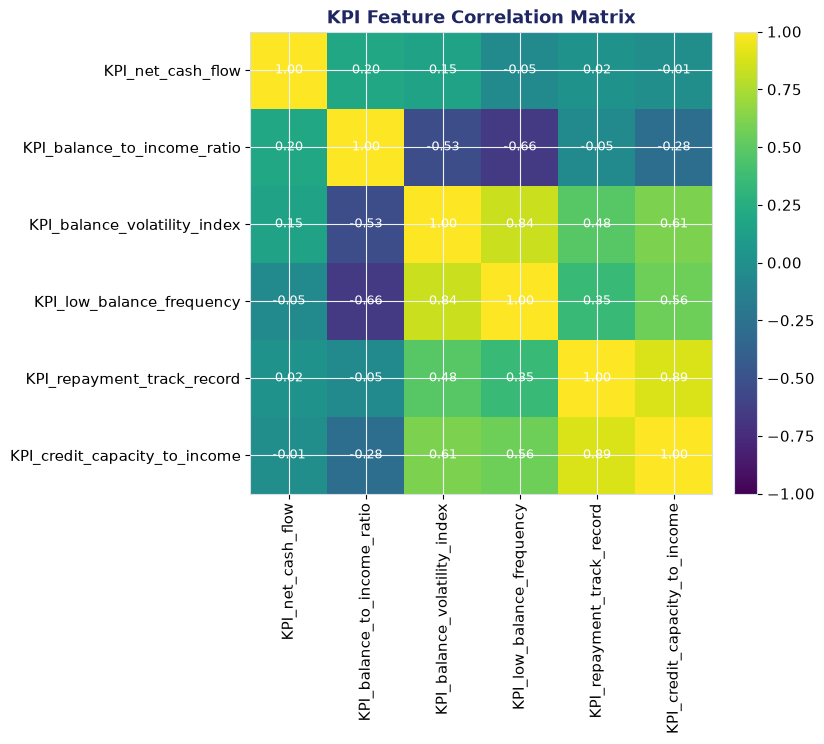

In [38]:
kpi_cols = ["KPI_net_cash_flow", "KPI_balance_to_income_ratio", "KPI_balance_volatility_index",
            "KPI_low_balance_frequency", "KPI_repayment_track_record", "KPI_credit_capacity_to_income"]
kpi_corr = eda.compute_kpi_correlation_matrix(customer_features, kpi_cols)
viz.plot_kpi_correlation_heatmap(kpi_corr)
plt.show()  # omit plt.show() in the pipeline script; use fig.savefig(...) there instead

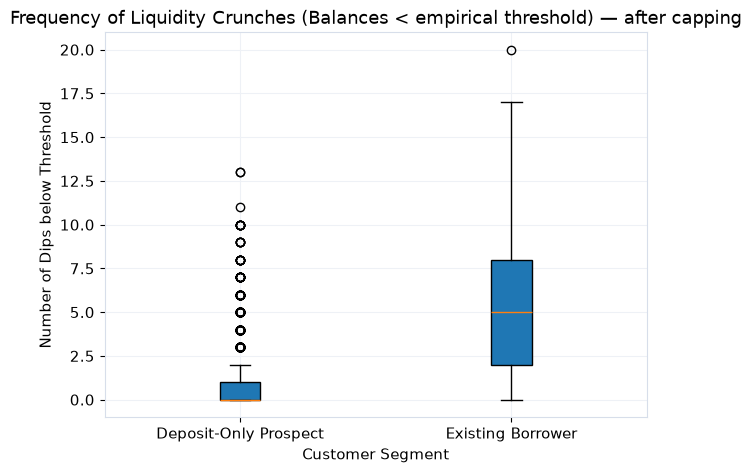

In [40]:
pdf = customer_features.select("customer_segment", "KPI_low_balance_frequency").toPandas()
order = sorted(pdf["customer_segment"].unique())
data = [pdf.loc[pdf["customer_segment"] == seg, "KPI_low_balance_frequency"] for seg in order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data, tick_labels=order, patch_artist=True)
ax.set_title("Frequency of Liquidity Crunches (Balances < empirical threshold) \u2014 after capping")
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Number of Dips below Threshold")
plt.show()

How the customer base splits by borrowing history, and by the Step-5
business-rule quadrant that will later score never-borrowed prospects
(Section 7).


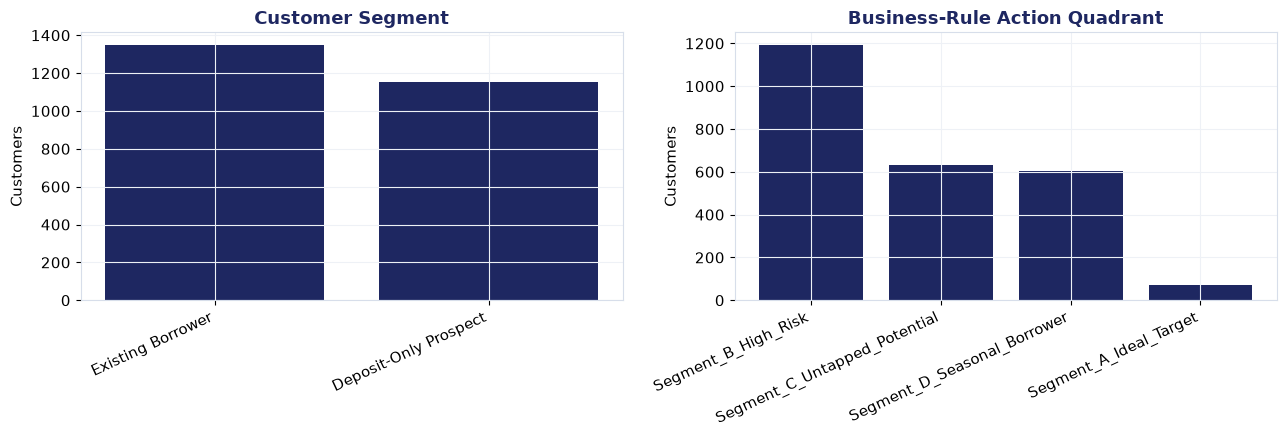

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
viz.plot_category_counts(customer_features, "customer_segment", "Customer Segment", ax=axes[0])
viz.plot_category_counts(customer_features, "KPI_action_quadrant", "Business-Rule Action Quadrant", ax=axes[1])
fig.tight_layout()
plt.show()


### Time-series view: portfolio burn rate by month

This was in the original pandas prototype (a monthly burn-rate trend line
plus a "top burners" bar chart) but got dropped when the notebook was
first ported to PySpark -- reinstated here on the same
`compute_burn_rate_detail` grain as the per-customer KPI above, just
aggregated by month (whole portfolio) instead of by customer.


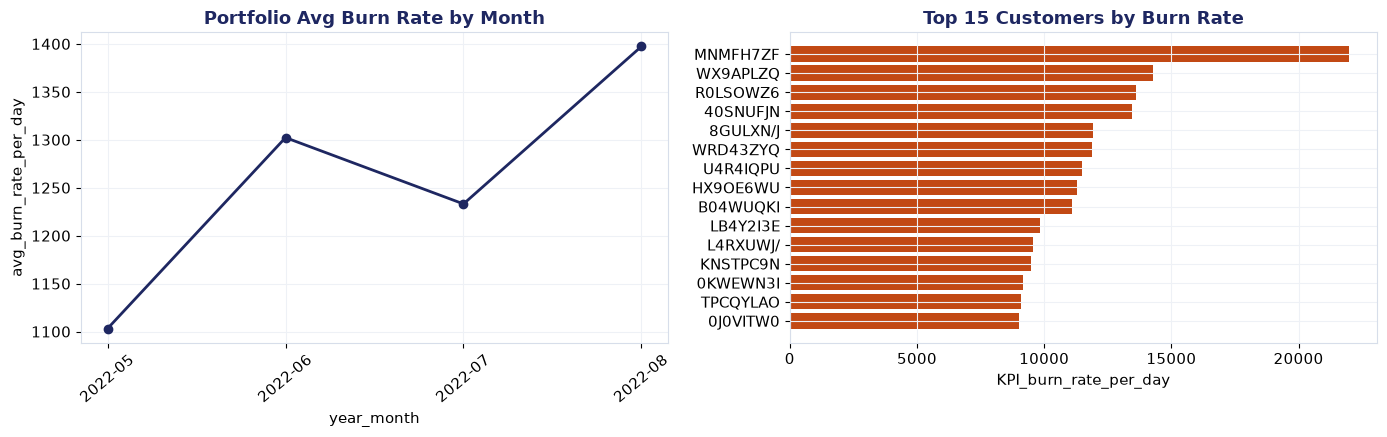

In [42]:
monthly_burn_trend = feat.compute_monthly_burn_rate_trend(transactions).toPandas()
top_burners_pdf = (
    customer_features.orderBy("KPI_burn_rate_per_day", ascending=False)
    .select("ID", "KPI_burn_rate_per_day")
    .limit(15)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
viz.plot_monthly_trend(monthly_burn_trend, "year_month", "avg_burn_rate_per_day",
                        "Portfolio Avg Burn Rate by Month", ax=axes[0])
viz.plot_top_n_bar(top_burners_pdf, "ID", "KPI_burn_rate_per_day",
                    "Top 15 Customers by Burn Rate", ax=axes[1])
fig.tight_layout()
plt.show()


## 4. EDA / data-quality report

Referential integrity, outlier and sentinel-value detection on INCOME and
loan AMOUNT, a negative-balance audit, a transaction-history-sufficiency
check, the raw class balance of the real label (`loans.OUTCOME`), and two
statistical checks (KS-test on INCOME by segment, chi-square on GENDER vs.
segment). This is the same report the production pipeline writes to
`reports/eda_report.yaml` on every run -- surfaced here for interactive
inspection.


In [43]:
eda_report = eda.run_full_eda_report(customers, loans, transactions, customer_features)
for section, result in eda_report.items():
    print(f"--- {section} ---")
    print(result)
    print()


--- referential_integrity ---
{'orphaned_loan_ids': 0, 'orphaned_transaction_ids': 0, 'passed': True}

--- income_outliers ---
{'column': 'INCOME', 'lower_bound': 7782.5, 'upper_bound': 12146.5, 'min_value': 6163.0, 'max_value': 13377.0, 'n_outliers': 69, 'pct_outliers': 2.76, 'n_sentinel_hits': 0}

--- loan_amount_outliers ---
{'column': 'AMOUNT', 'lower_bound': 10264.5, 'upper_bound': 29748.5, 'min_value': 7475.0, 'max_value': 33205.0, 'n_outliers': 33, 'pct_outliers': 1.03, 'n_sentinel_hits': 0}

--- negative_balance ---
{'n_negative_rows': 0, 'pct_negative_rows': 0.0, 'n_customers_ever_negative': 0, 'pct_customers_ever_negative': 0.0, 'max_overdraft_depth': None, 'avg_overdraft_depth': None}

--- transaction_history ---
{'low_history_percentile': 0.05, 'low_history_threshold': 29.0, 'n_customers_flagged': 177, 'pct_customers_flagged': 7.08}

--- class_balance ---
{'label_column': 'OUTCOME', 'total_rows': 3203, 'counts': {'Declined': 2745, 'TakeUp': 458}, 'percentages': {'Declined':

**Reading the checks above:**

- `referential_integrity`: flags any loan/transaction ID with no matching
  customer record -- a silent join failure otherwise.
- `income_outliers` / `loan_amount_outliers`: IQR bounds plus an explicit
  scan for placeholder sentinel values (9999, 99999, 999999, -1) that a
  bound-based check alone could miss if they happen to sit inside a wide
  distribution.
- `negative_balance`: how often, and how deeply, balances go negative --
  informs whether that's a valid overdraft state or a data artefact,
  without silently deciding for you (see `data_prep.clean_transactions`,
  which deliberately does not clip negative balances to zero).
- `transaction_history`: customers in the bottom percentile of
  transaction-count have noisier aggregates; flagged rather than trusted
  equally with everyone else.
- `class_balance`: the real label's balance, checked in EDA rather than
  discovered incidentally while building the train/test split.
- `income_distribution_shift` / `gender_segment_independence`: whether
  borrowers and prospects actually differ significantly on income (KS
  test), and whether segment membership is independent of gender
  (chi-square) -- both feed directly into the bias discussion below.

The chart below is the visual companion to the `income_distribution_shift`
KS-test above: it shows what the difference actually looks like, not just
whether it's statistically significant.


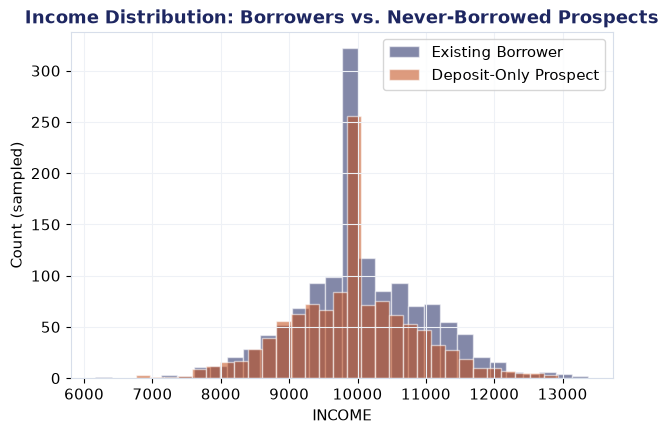

In [44]:
viz.plot_grouped_histogram(
    customer_features, "INCOME", "customer_segment",
    ["Existing Borrower", "Deposit-Only Prospect"],
    "Income Distribution: Borrowers vs. Never-Borrowed Prospects",
)
plt.show()


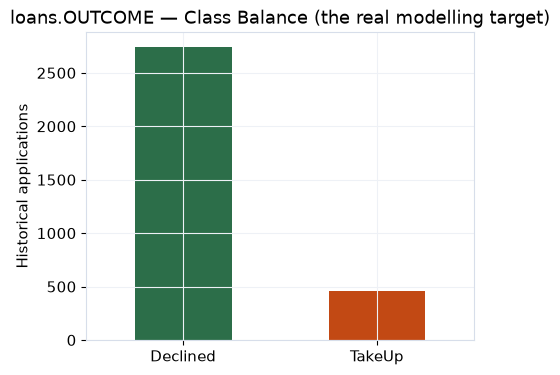

In [45]:
import pandas as pd

class_counts = eda_report["class_balance"]["counts"]
pd.Series(class_counts).plot(
    kind="bar", color=["#2C6E49", "#C24914"], figsize=(5, 4), rot=0,
    title="loans.OUTCOME — Class Balance (the real modelling target)",
)
plt.ylabel("Historical applications")
plt.show()


## 5. Build the loan-application-level table and train the model

The model is trained on `loans.OUTCOME` -- the one genuine historical
label in this dataset -- at loan-application grain, with point-in-time
loan-history features (`prior_loans_taken`, `prior_successful_loans`, etc.)
computed via window functions so that no application's own outcome leaks
into its own features. See `features.build_loan_level_features` for the
full reasoning, including the one known limitation that's documented
rather than silently ignored (transaction-based features are still
full-history aggregates, not re-computed per application date).


In [46]:
loan_level = feat.build_loan_level_features(loans, customer_features)
loan_level = model_lib.encode_gender(loan_level)

static_cols = feat.get_static_feature_columns(customer_features)
feature_columns = (
    [c for c in static_cols if c != "GENDER"]
    + ["GENDER_encoded", "GENDER_unknown"]
    + ["prior_loans_taken", "prior_successful_loans", "prior_max_loan_amount",
       "prior_repayment_track_record", "requested_amount"]
)


In [47]:
train_df, test_df = model_lib.train_test_split(loan_level)
print(f"train: {train_df.count()} rows, test: {test_df.count()} rows")
train_df.groupBy("TARGET_propensity").count().show()


train: 2633 rows, test: 570 rows
+-----------------+-----+
|TARGET_propensity|count|
+-----------------+-----+
|                1|  392|
|                0| 2241|
+-----------------+-----+



### Feature selection: variance -> VIF -> ANOVA

Run strictly on `train_df` -- **not** the full `loan_level` table -- so
the test set has no influence on which features are even allowed into
the model. That mirrors why the model itself only ever sees `train_df`
during fitting; letting feature selection see the test set first would
be the same category of leak we were careful to avoid with
`TARGET_propensity` and the point-in-time loan-history features earlier
in this notebook.

Three checks, each with its own chart: drop near-constant features (low
variance), prune multicollinear features by Variance Inflation Factor
(VIF > 10 = severe redundancy), then rank what's left by ANOVA F-test
discriminant power against `TARGET_propensity`. See
`src/feature_selection.py` for the full reasoning -- in particular, a
documented caveat about the `FLAG_SEG_*` one-hot family, which this
method doesn't reliably flag as collinear the way it does for ordinary
features.


Dropped (low variance): ['GENDER_unknown']


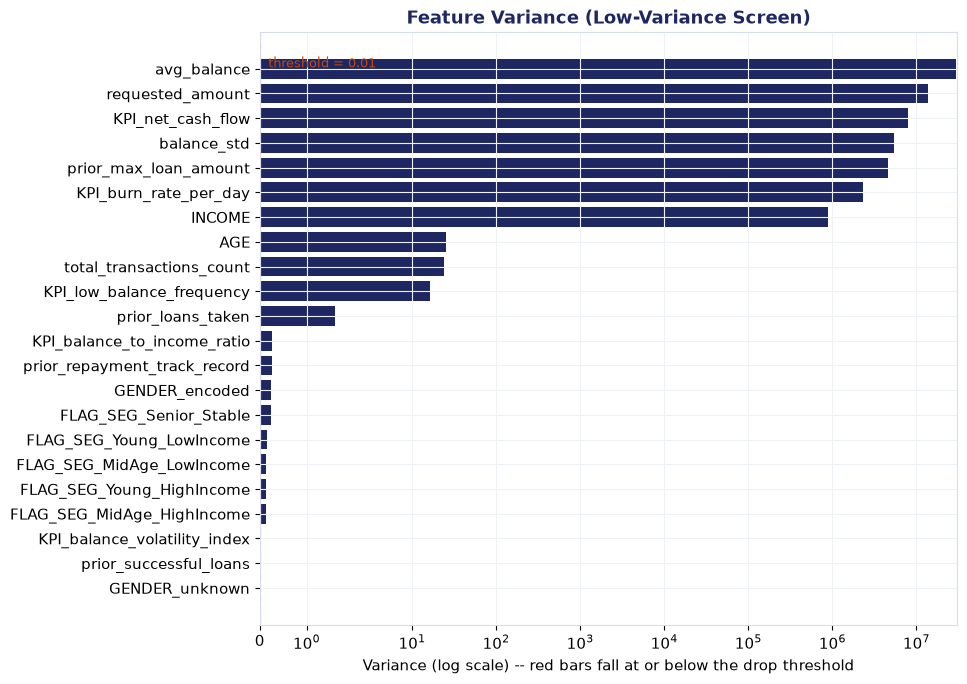

In [48]:
from src import feature_selection as fsel

VARIANCE_THRESHOLD = 0.01
feature_columns, dropped_low_variance, variances = fsel.drop_low_variance_features(
    train_df, feature_columns, threshold=VARIANCE_THRESHOLD
)
print("Dropped (low variance):", dropped_low_variance)

viz.plot_variance_scores(variances, threshold=VARIANCE_THRESHOLD)
plt.show()


VIF above ~10 is severe redundancy -- inspect the chart below before
deciding what (if anything) to drop by hand; the next cell applies an
automated version of the same decision (on the same `train_df`-only
basis) so the notebook and `pipelines/train_model.py` stay consistent.


--- VIF ---
                     Feature          VIF
      FLAG_SEG_Senior_Stable 3.246691e+13
    FLAG_SEG_Young_LowIncome 2.287787e+13
   FLAG_SEG_MidAge_LowIncome 1.834306e+13
   FLAG_SEG_Young_HighIncome 1.751279e+13
  FLAG_SEG_MidAge_HighIncome 1.732134e+13
                 avg_balance 1.607283e+02
 KPI_balance_to_income_ratio 1.430257e+02
                 balance_std 1.967274e+01
       prior_max_loan_amount 1.728938e+01
      prior_successful_loans 1.714126e+01
KPI_balance_volatility_index 1.436676e+01
                      INCOME 6.650785e+00
   KPI_low_balance_frequency 5.700608e+00
                         AGE 4.987539e+00
prior_repayment_track_record 2.388628e+00
           prior_loans_taken 2.288264e+00
           KPI_net_cash_flow 1.440406e+00
            requested_amount 1.391236e+00
    total_transactions_count 1.312678e+00
       KPI_burn_rate_per_day 1.255312e+00
              GENDER_encoded 1.104376e+00


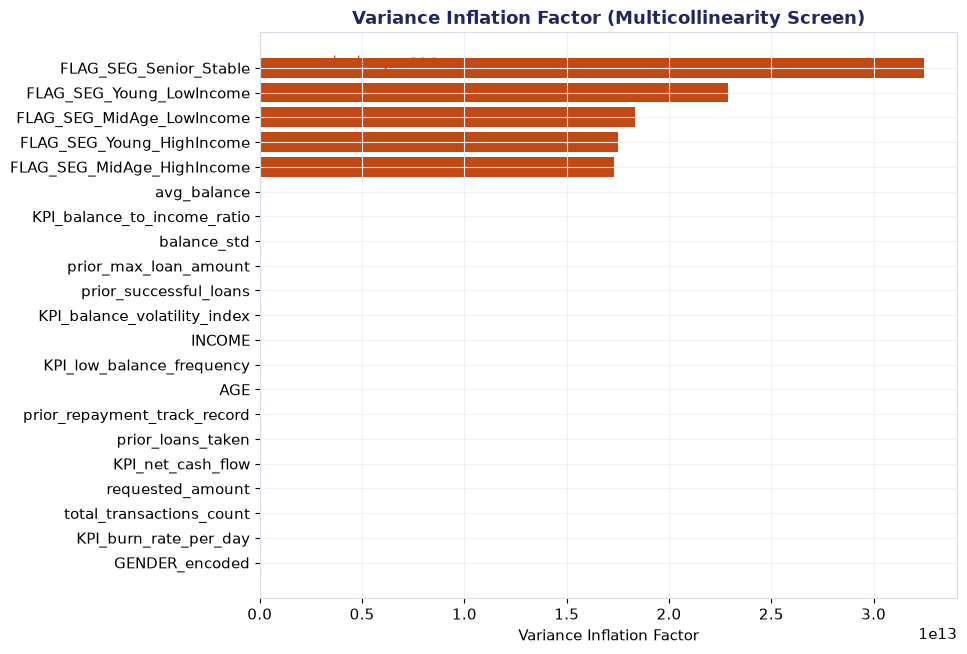

In [49]:
vif_scores = fsel.calculate_vif(train_df, feature_columns)
print("--- VIF ---")
print(vif_scores.to_string(index=False))

viz.plot_vif_scores(vif_scores, max_vif=10.0)
plt.show()


  Dropping 'FLAG_SEG_Senior_Stable' (VIF=32466910161233.07 > 10.0)
  Dropping 'avg_balance' (VIF=160.73 > 10.0)
  Dropping 'balance_std' (VIF=17.89 > 10.0)
  Dropping 'prior_max_loan_amount' (VIF=17.29 > 10.0)
Dropped (VIF pruning): ['FLAG_SEG_Senior_Stable', 'avg_balance', 'balance_std', 'prior_max_loan_amount']

--- Feature Discriminant Power Ranking ---
                     Feature  ANOVA_F_Score       p_value
 KPI_balance_to_income_ratio    1279.506675 1.048378e-228
   KPI_low_balance_frequency     502.888395 4.564389e-102
    total_transactions_count     212.820624  2.057781e-46
       KPI_burn_rate_per_day      87.665937  1.609329e-20
KPI_balance_volatility_index      81.340600  3.571282e-19
              GENDER_encoded      73.743667  1.497669e-17
                         AGE      37.945546  8.389651e-10
           KPI_net_cash_flow      30.672538  3.357072e-08
  FLAG_SEG_MidAge_HighIncome      13.031051  3.120875e-04
                      INCOME      12.771420  3.582811e-04
   

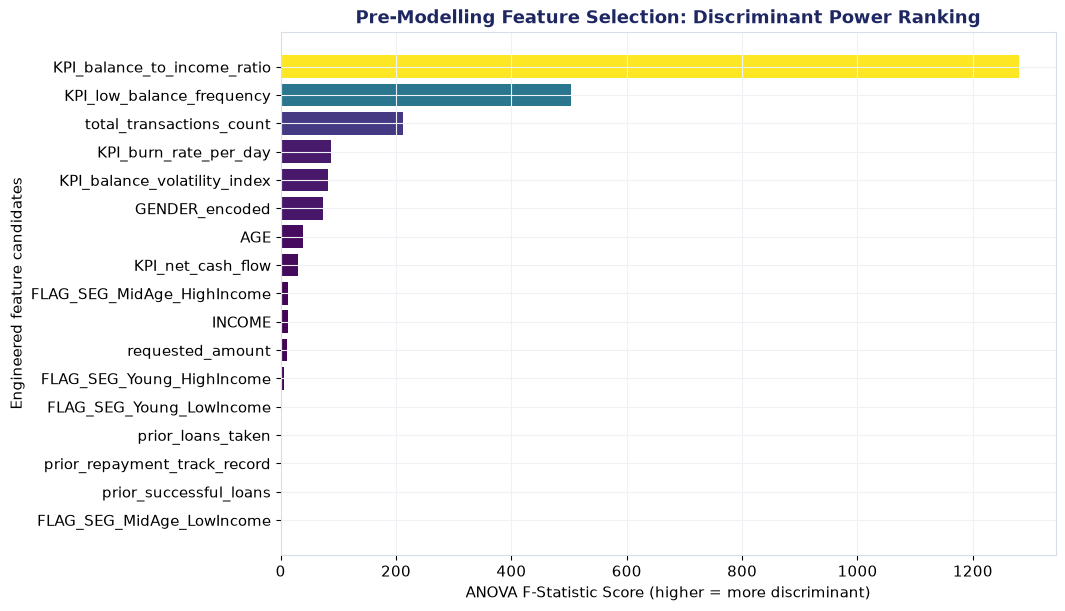

In [50]:
MAX_VIF = 10.0
feature_columns, dropped_vif = fsel.select_features_by_vif(train_df, feature_columns, max_vif=MAX_VIF)
print("Dropped (VIF pruning):", dropped_vif)

discriminant_scores = fsel.rank_features_anova(train_df, feature_columns, "TARGET_propensity")
print("\n--- Feature Discriminant Power Ranking ---")
print(discriminant_scores.to_string(index=False))

viz.plot_feature_selection_scores(discriminant_scores)
plt.show()


In [51]:
# Explicit checkpoint: this is the exact feature list the model below is
# about to be trained on -- printed on purpose so feature selection's
# effect on training is never just implied by an earlier cell having run.
print(f"Training with {len(feature_columns)} features after selection:")
for c in feature_columns:
    print(" -", c)


Training with 17 features after selection:
 - AGE
 - INCOME
 - total_transactions_count
 - KPI_net_cash_flow
 - KPI_balance_to_income_ratio
 - KPI_balance_volatility_index
 - KPI_low_balance_frequency
 - KPI_burn_rate_per_day
 - FLAG_SEG_Young_LowIncome
 - FLAG_SEG_MidAge_HighIncome
 - FLAG_SEG_Young_HighIncome
 - FLAG_SEG_MidAge_LowIncome
 - GENDER_encoded
 - prior_loans_taken
 - prior_successful_loans
 - prior_repayment_track_record
 - requested_amount


In [52]:
#pipeline_model, predictions, auc = model_lib.train_propensity_model(
#    train_df, test_df, feature_columns
#)
#print(f"Test-set ROC-AUC: {auc:.4f}")
#predictions.select("ID", "TARGET_propensity", "prediction", "probability").show(5, truncate=False)

REG_PARAM = 0.1
ELASTIC_NET_PARAM = 0.0  # pure L2 / Ridge

pipeline_model, predictions, auc = model_lib.train_propensity_model(
    train_df, test_df, feature_columns, reg_param=REG_PARAM, elastic_net_param=ELASTIC_NET_PARAM
)


In [53]:
gender_ablation = model_lib.assess_gender_contribution(
    train_df, test_df, feature_columns, reg_param=REG_PARAM, elastic_net_param=ELASTIC_NET_PARAM
)

ROC curve for the held-out test set, and the fitted model's coefficients
-- which features are actually pushing a prediction toward "would take up
the loan," and by how much, relative to each other (all features are
standardised, so magnitudes are directly comparable).


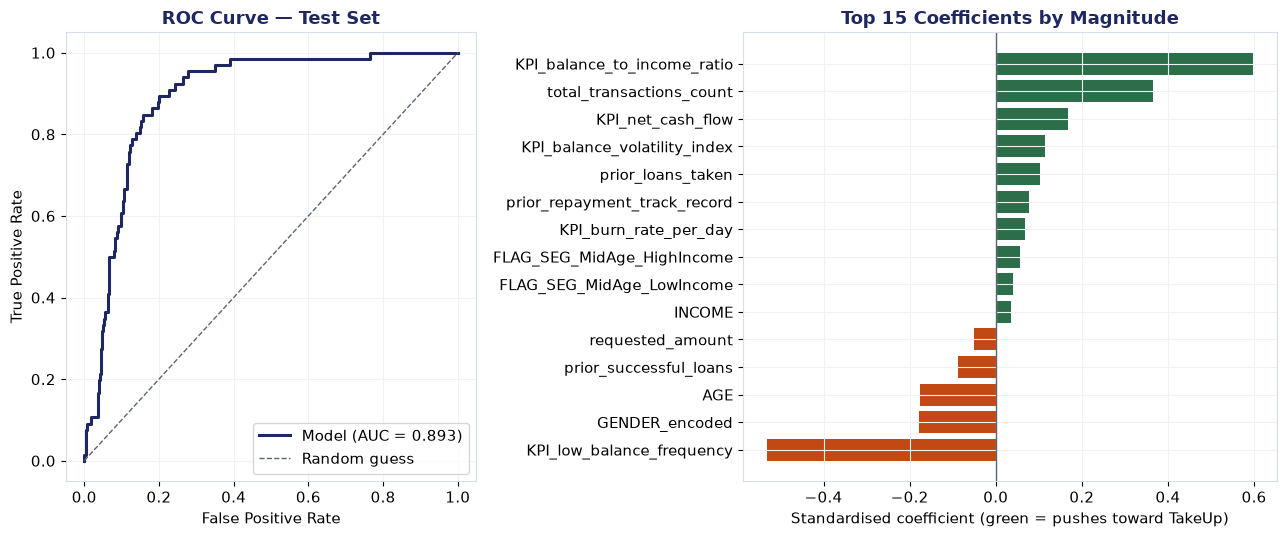

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1, 1.3]})
viz.plot_roc_curve(predictions, ax=axes[0])
viz.plot_coefficients(pipeline_model, feature_columns, ax=axes[1])
fig.tight_layout()
plt.show()


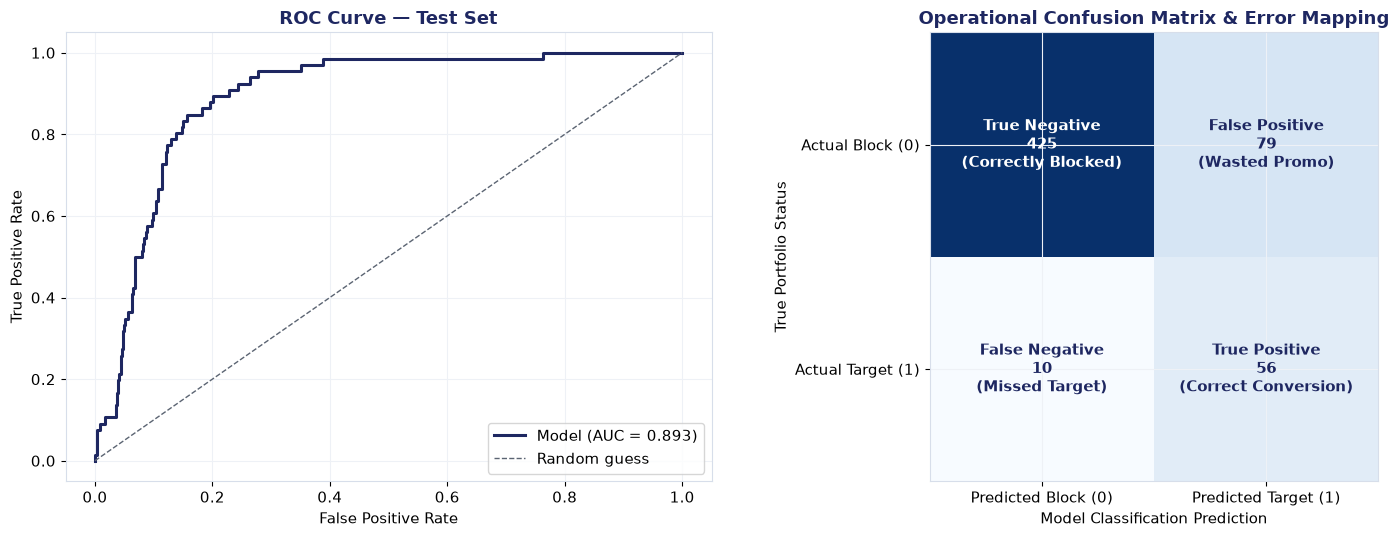

In [55]:
cm = model_lib.compute_confusion_matrix(predictions)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
viz.plot_roc_curve(predictions, ax=axes[0])
viz.plot_confusion_matrix(cm, ax=axes[1])
fig.tight_layout()
plt.show()

## 6. Bias & fairness assessment

The case study explicitly asks whether there's bias or discrimination in
the data. Two checks, run directly on the model's own predictions:

1. Predicted approval rate by gender and age band, plus the disparate
   impact ratio (the commonly-cited "four-fifths rule" -- a ratio below
   0.80 -- is used here only as a rough, widely-recognised benchmark for
   flagging something worth a closer look, not a legal threshold).
2. Whether GENDER is actually earning its place as a predictor, by
   comparing AUC with and without it. If the difference is small, keeping
   a protected characteristic in the model isn't buying much, and
   removing it is the more defensible default.


In [56]:
fairness = model_lib.fairness_report(predictions)
fairness


{'approval_rate_by_gender': {'Female': 0.3765182186234818,
  'Male': 0.13003095975232198},
 'approval_rate_by_age_band': {'36-50': 0.19343065693430658,
  '<=25': 0.5555555555555556,
  '26-35': 0.259927797833935,
  '51-65': 0.0},
 'disparate_impact_ratio_gender': 0.34535104364326374,
 'four_fifths_rule_flag': True}

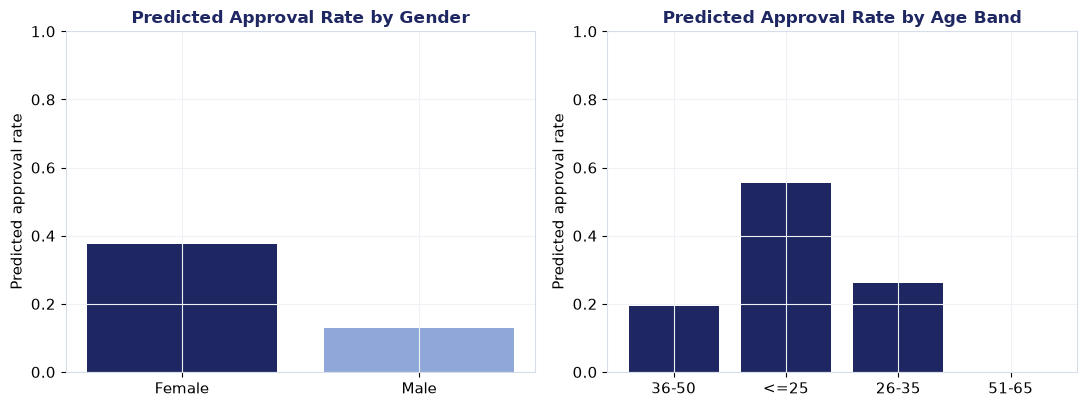

In [57]:
fig, axes = viz.plot_fairness_rates(fairness)
plt.show()


In [58]:
gender_ablation = model_lib.assess_gender_contribution(train_df, test_df, feature_columns)
gender_ablation


{'auc_with_gender': 0.8929773929773931,
 'auc_without_gender': 0.8851611351611356,
 'auc_difference': 0.0078162578162575,
 'interpretation': 'Gender adds little to no measurable predictive power here; excluding it from the live model costs little and removes a protected characteristic from a lending decision.'}

## 7. Score never-borrowed prospects

There is no real outcome to validate a model against for customers who
have never been offered a loan -- so their scores are reported alongside
the Step-5 business-rule quadrant (`KPI_action_quadrant`), rather than
presenting either alone as a validated answer. Treat the model column
below as a ranking signal for this group, not a tested probability.


In [62]:
prospects = model_lib.encode_gender(customer_features.filter("total_loans_taken = 0"))
prospects_for_scoring = (
    prospects
    .withColumn("prior_loans_taken", F.lit(0))
    .withColumn("prior_successful_loans", F.lit(0))
    .withColumn("prior_max_loan_amount", F.lit(0.0))
    .withColumn("prior_repayment_track_record", F.lit(-1.0))
    .withColumn("requested_amount", F.lit(0.0))
)

scored = pipeline_model.transform(prospects_for_scoring).withColumn(
    "probability_array", vector_to_array(F.col("probability"))
)
prospect_scores = scored.select(
    "ID", "customer_segment", "KPI_action_quadrant",
    F.col("probability_array").getItem(1).alias("model_propensity_score"),
)
prospect_scores.orderBy(F.col("model_propensity_score").desc()).show(10, truncate=False)


+--------+---------------------+----------------------------+----------------------+
|ID      |customer_segment     |KPI_action_quadrant         |model_propensity_score|
+--------+---------------------+----------------------------+----------------------+
|FI58QUTS|Deposit-Only Prospect|Segment_D_Seasonal_Borrower |0.9427486266555821    |
|SHLWYLWO|Deposit-Only Prospect|Segment_C_Untapped_Potential|0.9226001052164716    |
|TAZDLD5N|Deposit-Only Prospect|Segment_C_Untapped_Potential|0.9158619561801737    |
|RJR0L9NE|Deposit-Only Prospect|Segment_D_Seasonal_Borrower |0.909503008751602     |
|GIDHRFQ2|Deposit-Only Prospect|Segment_D_Seasonal_Borrower |0.9094097366449831    |
|WKYSXYK6|Deposit-Only Prospect|Segment_C_Untapped_Potential|0.9089765327692275    |
|LAZ2IB6N|Deposit-Only Prospect|Segment_C_Untapped_Potential|0.8928563204812445    |
|QXJDJKTT|Deposit-Only Prospect|Segment_C_Untapped_Potential|0.8915844150311759    |
|/XSNIWQ8|Deposit-Only Prospect|Segment_C_Untapped_Potential|0.89

In [63]:
#check the size of prospect_scores
prospect_scores.count()

1152

Does the model's extrapolated ranking broadly agree with the Step-5
business rule for this group? Large disagreement for a particular
quadrant is worth a second look before trusting the model's ranking over
the rule for that segment.


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

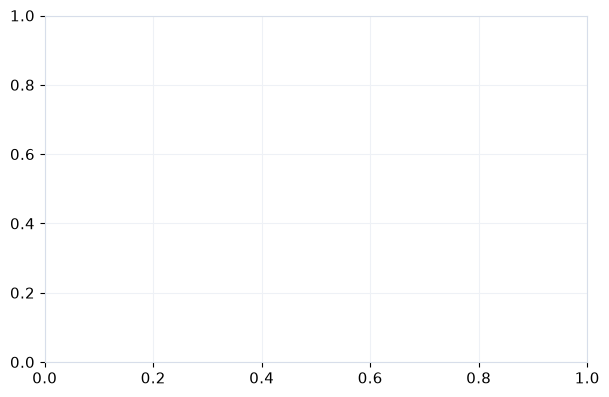

In [64]:
prospect_scores_pdf = prospect_scores.toPandas()  # this table is already small -- one row per prospect
viz.plot_prospect_scores(prospect_scores_pdf)
plt.show()


## Next steps

- Run `pipelines/train_model.py` to execute this same flow end-to-end and
  persist the model, EDA report, metrics (incl. fairness), and prospect
  scores to disk.
- `serving/app.py` still reflects the earlier scikit-learn feature set and
  has not yet been updated for this Spark pipeline -- see the project
  README for why that's a separate piece of work, and for the recommended
  interim pattern (batch scoring via `prospect_scores.parquet`, as above).
